Saved heatmaps/heatmap_initiate_collaboration.png
Saved heatmaps/heatmap_mean_f1_agent_0.png
Saved heatmaps/heatmap_mean_f1_agent_1.png
Saved heatmaps/heatmap_mean_redundancy_agent_0.png
Saved heatmaps/heatmap_mean_redundancy_agent_1.png
Saved heatmaps/heatmap_mean_similarity_agent_0.png
Saved heatmaps/heatmap_mean_similarity_agent_1.png
Saved heatmaps/heatmap_overall_collaboration.png
Saved heatmaps/heatmap_respond_collaboration.png
Saved heatmaps/heatmap_std_f1_agent_0.png
Saved heatmaps/heatmap_std_f1_agent_1.png
Saved heatmaps/heatmap_std_redundancy_agent_0.png
Saved heatmaps/heatmap_std_redundancy_agent_1.png
Saved heatmaps/heatmap_std_similarity_agent_0.png
Saved heatmaps/heatmap_std_similarity_agent_1.png
Saved heatmaps/heatmap_success_rate.png


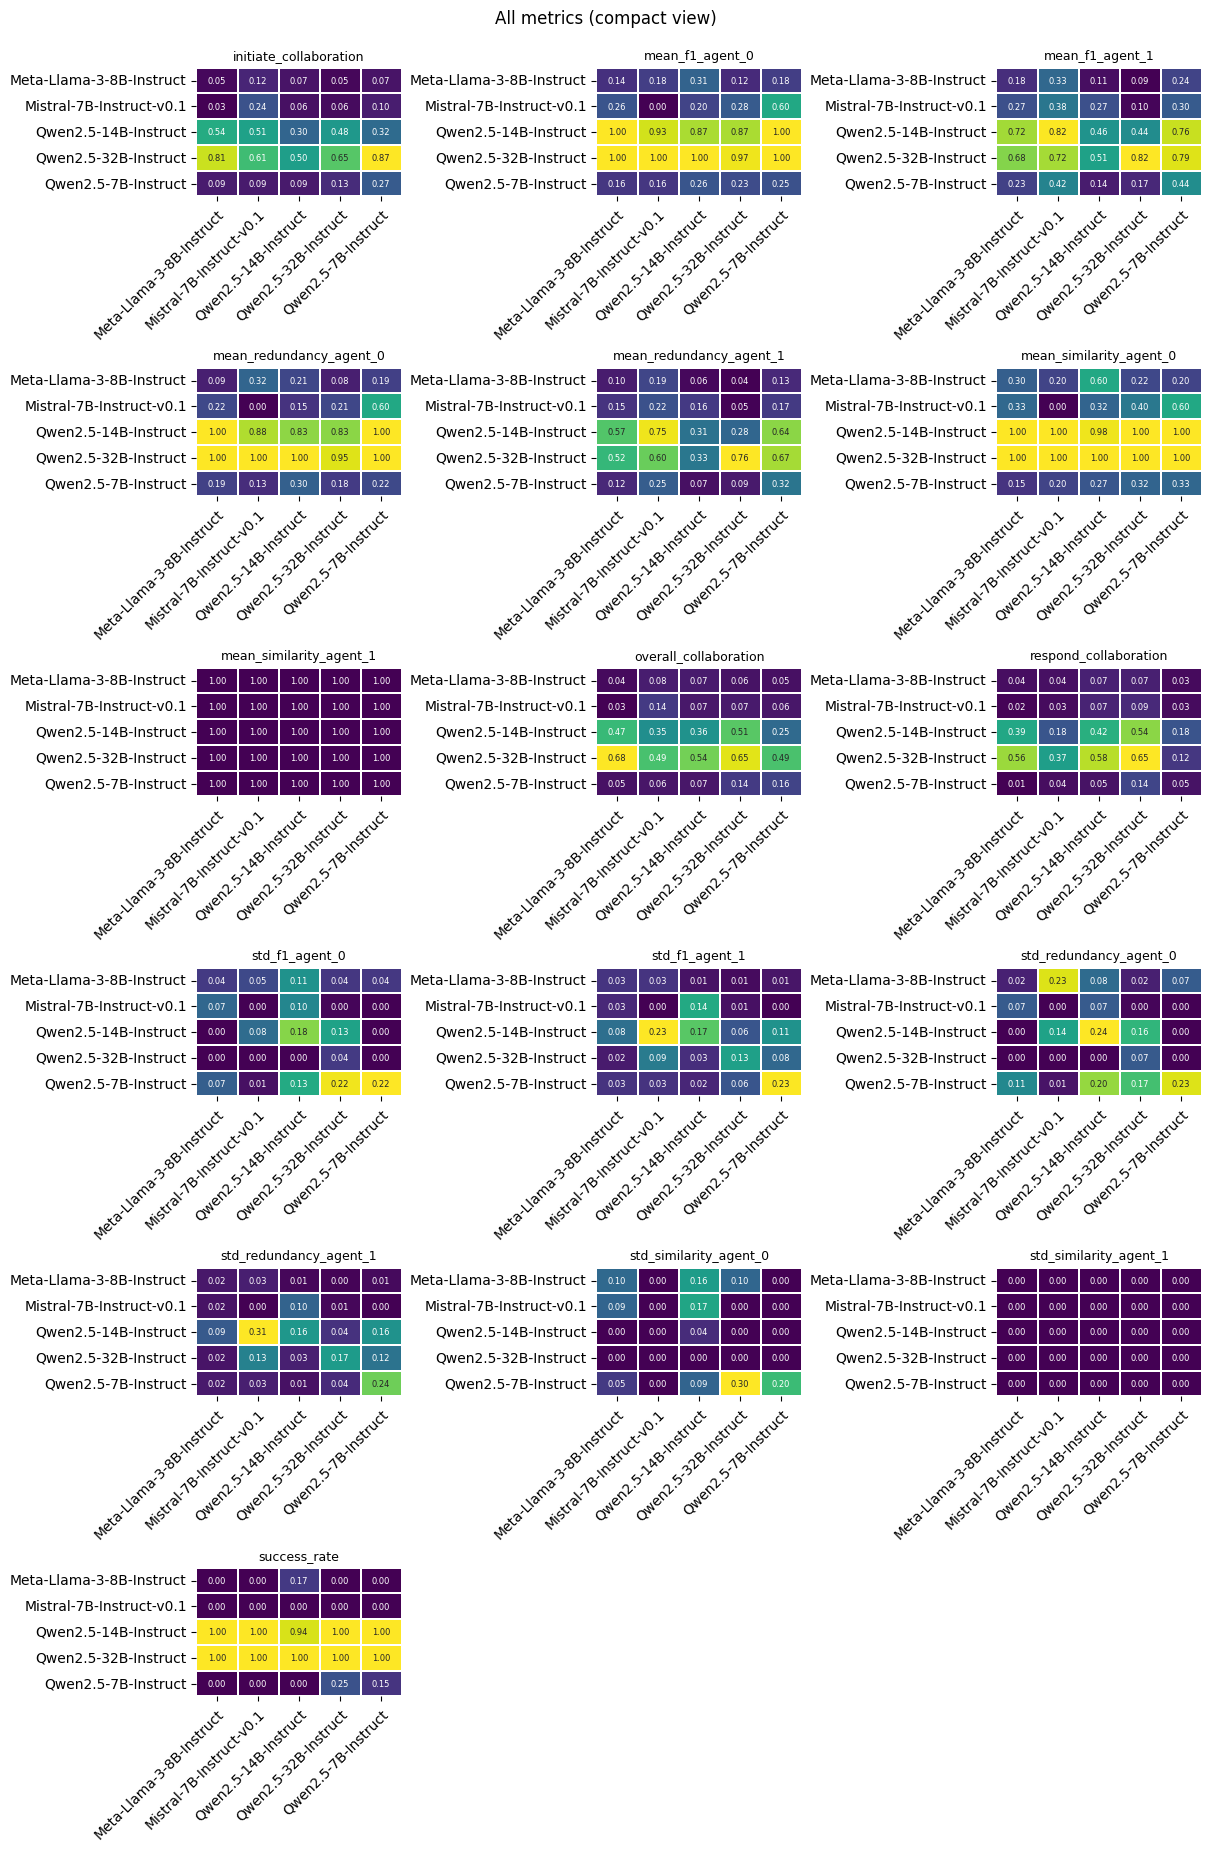

In [8]:
#!/usr/bin/env python
# -*- coding: utf-8 -*-
"""
Generate annotated heat‑maps for every numeric metric in converted_data.csv.
Each metric is saved as a PNG (full‑size) **and** shown inline in a compact
side‑by‑side grid when run in a Jupyter notebook.

Updated: 2025‑06‑30 — xtick labels diagonal; compact grid now shows numbers in
               every cell (smaller font to maintain readability).
"""

import math
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# ───────────────────────────────────────────────────────────────
# 1. Load and pre‑process
# ───────────────────────────────────────────────────────────────
csv_path = "converted_data_experiment_2025-07-07_temp_0.7.csv"  # adjust as needed
df = pd.read_csv(csv_path)

# Split the composite model column → agent0_model / agent1_model
parts = df["model"].str.split("_", expand=True)
df["agent0_model"] = parts[1]  # e.g. Qwen2.5-14B-Instruct
df["agent1_model"] = parts[3]

# Identify all numeric metrics (drop clearly non‑metric timing columns)
numeric_cols = (
    df.select_dtypes(include="number")
      .columns.difference(["level", "steps", "time_avg", "time_var"])
      .tolist()
)

# Aggregate duplicates: mean over (agent0, agent1, level)
group_cols = ["agent0_model", "agent1_model", "level"]
df_mean = (
    df.groupby(group_cols, dropna=False)[numeric_cols]
      .mean()
      .reset_index()
)

# ───────────────────────────────────────────────────────────────
# 2. Generate & save one heat‑map per metric
# ───────────────────────────────────────────────────────────────
out_dir = Path("heatmaps")
out_dir.mkdir(exist_ok=True)

pivots = {}  # store for composite inline plotting

for metric in numeric_cols:
    # rows = agent‑0, columns = agent‑1
    pivot = (
        df_mean
        .groupby(["agent0_model", "agent1_model"])[metric]
        .mean()
        .unstack(fill_value=np.nan)
    )
    pivots[metric] = pivot

    # Full‑size heat‑map (individual)
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(
        pivot,
        annot=True,
        fmt=".2f",
        cmap="viridis",
        linewidths=0.5,
        linecolor="white",
        cbar_kws={"label": metric},
        ax=ax,
    )

    ax.set_title(f"Mean {metric} (agent‑0 rows × agent‑1 columns)", pad=12)
    ax.set_xlabel("agent‑1 model")
    ax.set_ylabel("agent‑0 model")
    # Diagonal xtick labels to avoid overlap
    ax.set_xticklabels(
        ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor"
    )

    fig.tight_layout()
    outfile = out_dir / f"heatmap_{metric}.png"
    fig.savefig(outfile, dpi=300)
    plt.close(fig)
    print(f"Saved {outfile}")

# ───────────────────────────────────────────────────────────────
# 3. Composite inline view (compact grid)
# ───────────────────────────────────────────────────────────────
# Only executed in interactive environments (e.g., Jupyter Notebook)
try:
    n = len(numeric_cols)
    ncols = 3  # number of plots per row
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(ncols * 4, nrows * 3),
        squeeze=False,
        constrained_layout=True,
    )

    for idx, (metric, pivot) in enumerate(pivots.items()):
        r, c = divmod(idx, ncols)
        ax = axes[r][c]
        sns.heatmap(
            pivot,
            annot=True,            # numbers inside every square
            fmt=".2f",
            annot_kws={"size": 6},  # small font to avoid clutter
            cmap="viridis",
            linewidths=0.25,
            linecolor="white",
            cbar=False,
            ax=ax,
        )
        ax.set_title(metric, fontsize=9)
        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.set_xticklabels(
            ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor"
        )
        ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

    # Hide any unused axes
    for idx in range(n, nrows * ncols):
        r, c = divmod(idx, ncols)
        axes[r][c].axis("off")

    fig.suptitle("All metrics (compact view)", y=1.02, fontsize=12)
    plt.show()
except Exception:
    # Fail quietly outside interactive sessions
    pass


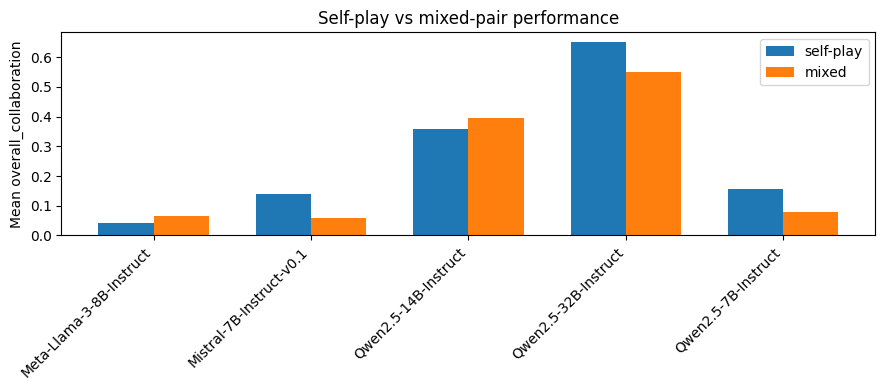

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ───────────────────────────────────────────────────────────────
# split the “family_model_family_model” string
parts = df['model'].str.split('_', expand=True)
df['agent0'] = parts[1]     # e.g. Qwen2.5-14B-Instruct
df['agent1'] = parts[3]

# average repeated runs per unordered pair
metric = 'overall_collaboration'             # pick the metric you want
df_mean = (
    df.groupby(['agent0', 'agent1'])[metric]
      .mean()
      .reset_index()
)

# classify each row as self-play or mixed
df_mean['pair_type'] = np.where(
    df_mean['agent0'] == df_mean['agent1'],
    'self-play',
    'mixed',
)

# ───────────────────────────────────────────────────────────────
# 2. Pivot so each model gets two columns: self-play | mixed
# ───────────────────────────────────────────────────────────────
pivot = (
    df_mean.pivot_table(index='agent0',  # one row per *reference* model
                        columns='pair_type',
                        values=metric)
          .reindex(columns=['self-play', 'mixed'])   # consistent order
          .sort_index()
)

# ───────────────────────────────────────────────────────────────
# 3. Bar plot
# ───────────────────────────────────────────────────────────────
models      = pivot.index.tolist()
x           = np.arange(len(models))
bar_width   = 0.35
colors      = {'self-play': '#1f77b4', 'mixed': '#ff7f0e'}

fig, ax = plt.subplots(figsize=(9, 4))

# plot each category
for i, category in enumerate(pivot.columns):
    ax.bar(
        x + (i - 0.5) * bar_width,      # centre bars around each tick
        pivot[category],                # NaN automatically not plotted
        width = bar_width,
        label = category,
        color = colors[category],
    )

# cosmetics
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=45, ha='right')
ax.set_ylabel(f'Mean {metric}')
ax.set_title('Self-play vs mixed-pair performance')
ax.legend()
fig.tight_layout()
plt.show()


In [11]:
import networkx as nx
from io import StringIO
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import euclidean_distances
from scipy.cluster.hierarchy import linkage, dendrogram
from math import pi

In [12]:
# Split combined model string into initiator and responder
df[["initiator", "responder"]] = df["model"].str.split("_", n=1, expand=True)
df["initiator_family"] = df["initiator"].str.split("-").str[0]
df["responder_family"] = df["responder"].str.split("-").str[0]

# Derived asymmetry columns
for metric in ["mean_f1", "mean_similarity", "mean_redundancy"]:
    df[f"delta_{metric}"] = df[f"{metric}_agent_1"] - df[f"{metric}_agent_0"]

# Convenience for self-play vs cross-play
df["self_play"] = (df["initiator"] == df["responder"])

print("Data loaded:", df.shape)

Data loaded: (25, 33)


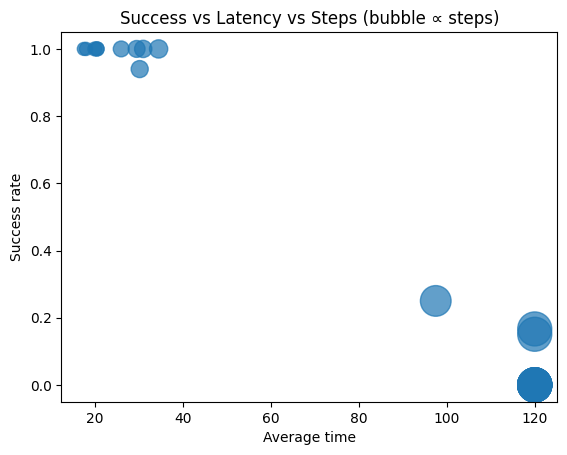

In [13]:
# ───────────────────────────────────────────────────────────────
# 4. Success–time–steps bubble chart
# ───────────────────────────────────────────────────────────────
def bubble_success_time(data):
    plt.figure()
    sizes = data["steps"] * 5
    plt.scatter(data["steps"], data["success_rate"], s=sizes, alpha=0.7)
    plt.xlabel("Average time")
    plt.ylabel("Success rate")
    plt.title("Success vs Latency vs Steps (bubble ∝ steps)")
    plt.show()

bubble_success_time(df)


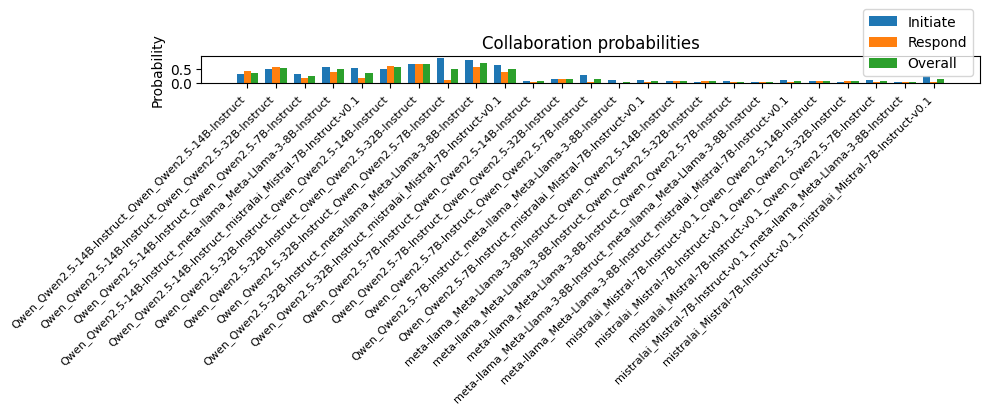

In [14]:
# ───────────────────────────────────────────────────────────────
# 6. Grouped bar chart of collaboration probabilities
# ───────────────────────────────────────────────────────────────
def grouped_collab_bars(data):
    labels = data["model"]
    x      = np.arange(len(labels))
    w      = 0.25
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.bar(x - w, data["initiate_collaboration"], width=w, label="Initiate")
    ax.bar(x,      data["respond_collaboration"], width=w, label="Respond")
    ax.bar(x + w, data["overall_collaboration"],  width=w, label="Overall")
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=8)
    ax.set_ylabel("Probability")
    ax.set_title("Collaboration probabilities")
    ax.legend()
    plt.tight_layout()
    plt.show()

grouped_collab_bars(df)
